Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


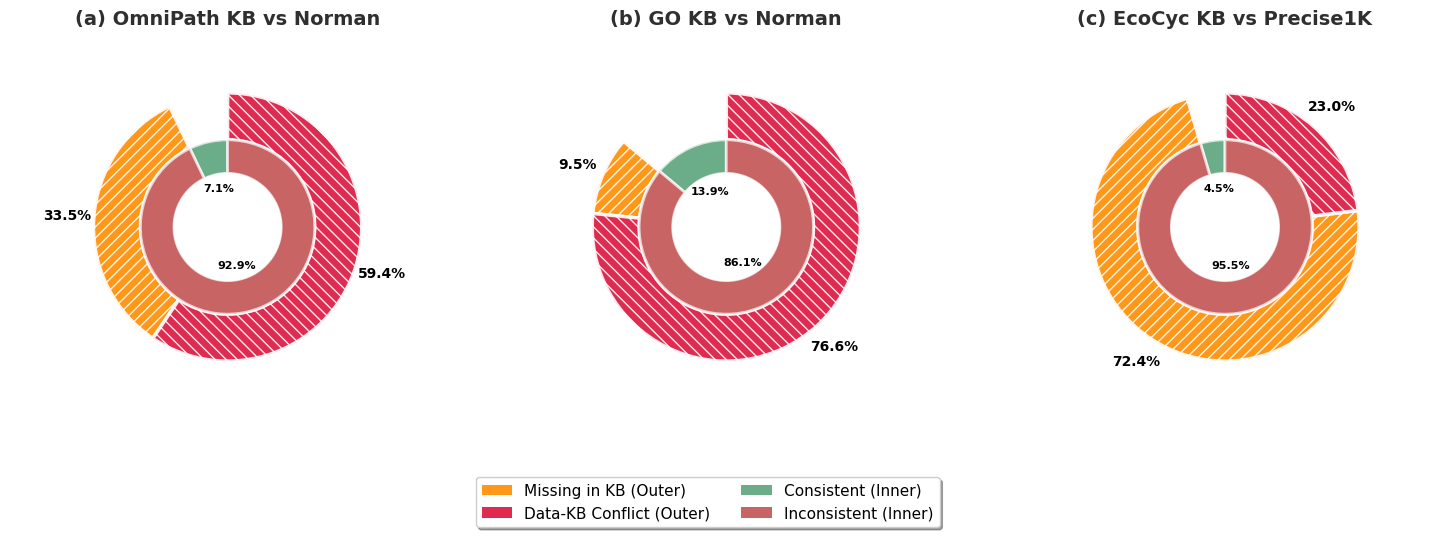

In [ ]:
import numpy as np
import torch
from scipy.sparse import load_npz
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import json
import gc
import pandas as pd

from egoal.reasoner import RegulatoryKB
from egoal.learner_refl import ReflectLearner


# mpl.rcParams['text.usetex'] = True
# mpl.rcParams['font.family'] = 'Times New Roman'
# #mpl.rcParams['font.serif'] = ['Times New Roman']
# plt.rcParams['mathtext.fontset'] = 'custom'
# plt.rcParams['mathtext.rm'] = 'Times New Roman'
# plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
# plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'

plt.rcParams.update({
    "pgf.texsystem": "pdflatex",
    "pgf.preamble": r"\usepackage[utf8]{inputenc}\usepackage[T1]{fontenc}",
})

combs = [('norman', 'omnipath'), ('norman', 'go'),
         ('dixit', 'omnipath'), ('dixit', 'go'),
         ('adamson', 'omnipath'), ('adamson', 'go'),
         ('precise1k', 'ecocyc'), ('ncbi-sra', 'ecocyc')]
device = 'cuda'

incons_dict_path = 'data_anal/incons_plots/incons_edges.json'
if not os.path.exists(incons_dict_path):
    incons_dict= {}
    for data_name, kb_name in combs:
        print(f'processing {data_name} data + {kb_name} kb')

        if data_name not in ['precise1k','ncbi-sra']:
            Y = load_npz(f'dataset/human/{data_name}_Y.npz').toarray()
            X = load_npz(f'dataset/human/{data_name}_X.npz').toarray()
        else:
            label_set = pd.read_csv('dataset/label_set_iml.csv', index_col=0)
            Y = np.load(f'dataset/{data_name}/Y_label.npy')[:,list(label_set[\
                    'precise1k_idx' if data_name=='precise1k' else 'matrix_idx'])]
            X = np.load(f'dataset/{data_name}/X_label.npy')
        
        if kb_name == 'go':
            Y = np.abs(Y)

        
        #if os.path.exists(f'data_anal/incons_plots/data/{data_name}_Y_d.npy'):
        #    Y_deduction = np.load(f'data_anal/incons_plots/data/{data_name}_Y_d.npy')
        #else:
        KB = RegulatoryKB(pos_trn_pth=f'data_anal/incons_plots/data/{data_name}_{kb_name}_KB_P.npz',\
                neg_trn_pth=f'data_anal/incons_plots/data/{data_name}_{kb_name}_KB_N.npz'\
                if kb_name!='go' else None, device=device)
        KB.closure_(T=5, closure_type='weighted' if kb_name!='go' else 'naive')
        
        Y_deduction = KB.deduce(torch.tensor(X).float().to(device)).to('cpu').numpy()
            #np.save(f'data_anal/incons_plots/data/{data_name}_Y_d.npy', Y_deduction)

        if data_name in ['precise1k','ncbi-sra']:
            Y_deduction = Y_deduction[:,list(label_set['matrix_idx'])]
        
        n_consit = np.sum((Y == Y_deduction) & (Y != 0))
        n_incomp = np.sum((Y != Y_deduction) & (Y_deduction == 0))
        n_incons = np.sum((Y != Y_deduction) & (Y_deduction != 0))
        n_empty = np.sum((Y == Y_deduction) & (Y_deduction == 0))
        total = n_consit + n_incomp + n_incons + n_empty
        n_consit, n_incomp, n_incons, n_empty = n_consit/total, n_incomp/total, n_incons/total, n_empty/total

        res = {'consistent': n_consit, 'missing': n_incomp, 'conflict': n_incons, 'empty': n_empty}
        incons_dict[str((data_name, kb_name))] = res

        del KB
        gc.collect()
        torch.cuda.empty_cache()

    json.dump(incons_dict, open(incons_dict_path, 'w'), indent=4)

else:
    incons_dict = json.load(open(incons_dict_path,'r'))


# Select only the three specific combinations requested
selected_combinations = [
    ('norman', 'omnipath'),   # (a) Omnipath KB vs Norman dataset
    ('norman', 'go'),         # (b) Go KB vs Norman dataset  
    ('precise1k', 'ecocyc')   # (c) Ecocyc KB vs Precise1k dataset
]

# Collect data for the selected combinations only
plot_data = []
for data_name, kb_name in selected_combinations:
    key = str((data_name, kb_name))
    if key in incons_dict:
        v = incons_dict[key]
        n_consit = v['consistent']
        n_incomp = v['missing']
        n_incons = v['conflict']
        plot_data.append((data_name, kb_name, n_consit, n_incomp, n_incons))

# Create publication-quality figure with improved layout
n_plots = len(plot_data)
fig, axes = plt.subplots(1, n_plots, figsize=(15, 5))  # Better aspect ratio for paper
if n_plots == 1:
    axes = [axes]  # Ensure axes is always a list

# Publication-quality color palette - using professional colors
# Color-blind friendly palette with high contrast
consistent_color = '#2E8B57'      # Sea Green - for consistent interactions
missing_color = '#FF8C00'        # Dark Orange - for missing in KB
conflict_color = '#DC143C'       # Crimson - for conflicts
inconsistent_color = '#B22222'   # Fire Brick - for overall inconsistent

# Define colors and labels for legend
categories = ['Consistent', 'Missing in KB', 'Data-KB Conflict']
colors = [consistent_color, missing_color, conflict_color]
inner_categories = ['Consistent', 'Inconsistent']
inner_colors = [consistent_color, inconsistent_color]

# Create clean legend elements
from matplotlib.patches import Patch
legend_elements = []
# Legend for outer ring - only inconsistent categories (with gap for consistent)
outer_inconsistent_categories = ['Missing in KB', 'Data-KB Conflict']
# Legend for inner ring - complete categories
legend_elements.extend([Patch(facecolor=inner_colors[i], label=f'{inner_categories[i]} (Inner)', alpha=0.7) 
                       for i in range(len(inner_categories))])
outer_inconsistent_colors = [missing_color, conflict_color]
legend_elements.extend([Patch(facecolor=outer_inconsistent_colors[i], label=f'{outer_inconsistent_categories[i]} (Outer)', alpha=0.9) 
                       for i in range(len(outer_inconsistent_categories))])


# Define subplot labels with better formatting
subplot_labels = ['(a)', '(b)', '(c)']
kb_display_names = {'omnipath': 'OmniPath', 'go': 'GO', 'ecocyc': 'EcoCyc'}
data_display_names = {'norman': 'Norman', 'precise1k': 'Precise1K'}

for idx, (data_name, kb_name, n_consit, n_incomp, n_incons) in enumerate(plot_data):
    ax = axes[idx]
    
    ax.axis('equal')  # Equal aspect ratio ensures the pie is circular
    
    # Create outer ring with gaps - add all categories but make consistent invisible
    outer_values = [n_consit, n_incomp, n_incons]
    outer_colors = ['white', missing_color, conflict_color]  # White for consistent (will be made transparent)
    outer_labels = ['', '', '']  # No labels - only percentages
    
    # Create the full pie chart first with hatching patterns for better distinction
    wedges, texts, autotexts = ax.pie(outer_values,
                                     colors=outer_colors,
                                     labels=outer_labels,
                                     radius=1.0,
                                     startangle=90,
                                     wedgeprops=dict(width=0.35, edgecolor='white', linewidth=2.5, alpha=0.9),
                                     autopct='%1.1f%%',
                                     pctdistance=1.2,  # Move percentages outside the outer ring
                                     textprops={'fontsize': 10, 'fontweight': 'bold', 'color': 'black'})  # Black text for better contrast outside
    
    # Add hatching patterns to outer ring wedges for better distinction
    # Different hatch patterns for each category
    hatch_patterns = ['', '///', '\\\\\\']  # No hatch for consistent (invisible), diagonal lines for others
    for i, wedge in enumerate(wedges):
        if i > 0:  # Don't hatch the invisible consistent segment
            wedge.set_hatch(hatch_patterns[i])
            wedge.set_linewidth(2.5)  # Maintain edge thickness
    
    # Make the consistent segment (first one) completely invisible to create the gap
    wedges[0].set_alpha(0)
    wedges[0].set_edgecolor('none')  # Remove edge too
    
    # Also hide the text for the consistent segment
    if autotexts[0]:
        autotexts[0].set_alpha(0)
    
    # Inner ring: complete circle with all categories
    inner_values = [n_consit, n_incomp + n_incons]
    inner_colors = [consistent_color, inconsistent_color]
    inner_wedges, inner_texts, inner_autotexts = ax.pie(inner_values,
                                                        colors=inner_colors,
                                                        radius=0.65,
                                                        startangle=90,
                                                        wedgeprops=dict(width=0.25, edgecolor='white', linewidth=2, alpha=0.7),
                                                        autopct='%1.1f%%',
                                                        pctdistance=0.45,  # Closer to center for better visibility
                                                        textprops={'fontsize': 8, 'fontweight': 'bold', 'color': 'black'})  # Black text for contrast
    
    # Add center circle with subtle shadow effect
    centre_circle = plt.Circle((0, 0), 0.4, color='white', alpha=0.95)
    ax.add_artist(centre_circle)
    
    # Improved subplot titles with better formatting
    kb_name_display = kb_display_names.get(kb_name, kb_name.capitalize())
    data_name_display = data_display_names.get(data_name, data_name.capitalize())
    ax.set_title(f'{subplot_labels[idx]} {kb_name_display} KB vs {data_name_display}', 
                fontsize=14, fontweight='bold', pad=25, color='#2F2F2F')

# Add publication-quality legend
legend = fig.legend(handles=legend_elements, 
                   loc='lower center', 
                   bbox_to_anchor=(0.5, -0.08),
                   ncol=2, 
                   frameon=True,
                   fancybox=True,
                   shadow=True,
                   fontsize=11,
                   title='',
                   title_fontsize=12)
legend.get_title().set_fontweight('bold')

# Set overall figure background
fig.patch.set_facecolor('white')
fig.patch.set_alpha(1.0)

plt.tight_layout()
plt.subplots_adjust(bottom=0.2)  # More room for enhanced legend

# Save in multiple formats for publication
plt.savefig(f'data_anal/incons_plots/piechart_publication_quality.pdf', 
           dpi=300, format='pdf', bbox_inches='tight', 
           facecolor='white', edgecolor='none')
plt.savefig(f'data_anal/incons_plots/piechart_publication_quality.png', 
           dpi=300, format='png', bbox_inches='tight',
           facecolor='white', edgecolor='none')
plt.savefig(f'data_anal/incons_plots/piechart_publication_quality.pgf', 
           dpi=300, format='pgf', bbox_inches='tight',
           facecolor='white', edgecolor='none')
plt.show()
